In [19]:
import warnings
warnings.filterwarnings("ignore")

In [20]:
import torch
import numpy as np
import chemcoord as cc
import pandas as pd
import matplotlib.pyplot as plt

from ase.io.trajectory import Trajectory
from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.silver_isomers_utils import (
    get_molecule_isomer_minima,
    get_construction_table
)

In [21]:
# Define the working directory
working_dir = "/home/amolina/ab-flowMC/ag8"
molecular_dynamics_dir = working_dir + "/1-molecular-dynamics"

# 1. Molecular dynamics trajectories

In [22]:
# Load the trajectories
trajs_ag8 = {'0': Trajectory(
    molecular_dynamics_dir + "/molecular_dynamics_ag8_0_20240902035647.traj"
    ),
             '1': Trajectory(
    molecular_dynamics_dir + "/molecular_dynamics_ag8_1_20240902065506.traj"
    )}

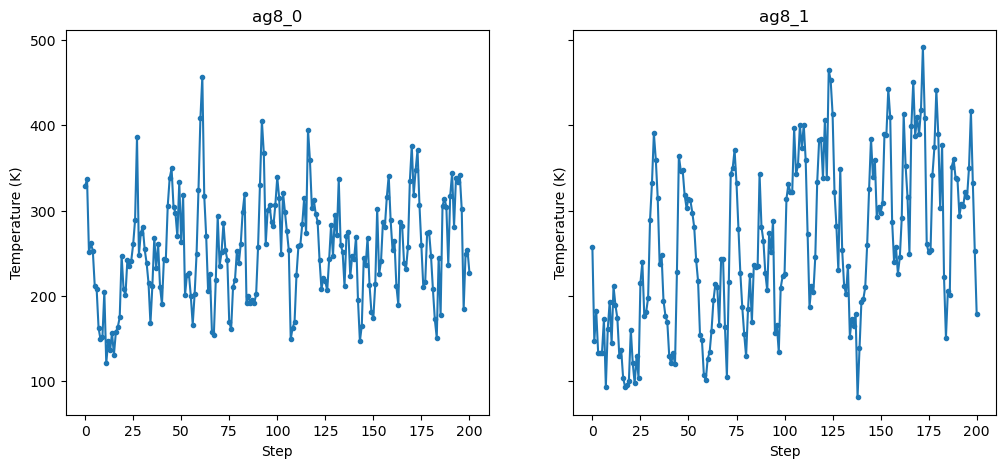

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, ag8 in trajs_ag8.items():
    temperature = [atoms.get_temperature() for atoms in ag8]
    axs[int(i)].plot(temperature, '.-')
    axs[int(i)].set_xlabel('Step')
    axs[int(i)].set_ylabel('Temperature (K)')
    axs[int(i)].set_title(f'ag8_{i}')

# 2. Internal coordinates

In [24]:
cartesian = cc.Cartesian.from_ase_atoms(get_molecule_isomer_minima('FD-TPSS', 'ag8', 0))
zmat = cartesian.get_zmat()
construction_table = cartesian.get_construction_table()

print("ZMAT: Internal coordinates for isomer 0 of ag8")
zmat

ZMAT: Internal coordinates for isomer 0 of ag8


,atom,b,bond,a,angle,d,dihedral
6,Ag,$\vec{0}$,13.446089,$\vec{e_z}$,55.647465,$\vec{e_x}$,45.201584
0,Ag,6,2.793928,$\vec{e_z}$,35.249279,$\vec{e_x}$,52.827586
1,Ag,0,2.743090,6,59.293732,$\vec{e_x}$,-88.082961
2,Ag,0,2.742639,1,112.623159,6,27.355776
4,Ag,2,2.737163,0,61.728378,1,-98.553623
5,Ag,4,2.737969,2,112.104411,0,98.635043
7,Ag,5,2.738895,4,61.644410,2,-99.345051
3,Ag,7,2.737317,5,112.029030,4,-27.412233


In [25]:
print("Construction table: Using internal coordinates for isomer 0 of ag8 as reference")
construction_table

Construction table: Using internal coordinates for isomer 0 of ag8 as reference


,b,a,d
6,origin,e_z,e_x
0,6,e_z,e_x
1,0,6,e_x
2,0,1,6
4,2,0,1
5,4,2,0
7,5,4,2
3,7,5,4


In [26]:
print("Construction table saved in utils.silver_isomers_utils for ag8")
get_construction_table('ag8')

Construction table saved in utils.silver_isomers_utils for ag8


,b,a,d
6,origin,e_z,e_x
0,6,e_z,e_x
1,0,6,e_x
2,0,1,6
4,2,0,1
5,4,2,0
7,5,4,2
3,7,5,4


In [27]:
# Coordinates mapping object for ag8

construction_table = get_construction_table('ag8')
coord_maps = Coordinates_mapping(construction_table=construction_table,
                                 calculator_label='FD-TPSS',
                                 chemical_formula='Ag8',
                                 etype='dft')

In [28]:
zmat = coord_maps.zmat_minima[0]
molecule = coord_maps.build_molecule_from_zmat(zmat)
isomer_minima = get_molecule_isomer_minima('FD-TPSS', 'Ag8', '0')

sum_reconstruction_error = (isomer_minima.get_all_distances() - molecule.get_all_distances()).std()

sum_reconstruction_error

1.074481248724363e-07

## 2.a Reconstruction of MD trajectory from RC coordinates to molecules  objects

In [29]:
database_dir = working_dir + "/database" 

In [30]:
database_filenames = {'0': "database_ag8_0_20240910204355_rc.csv",
                        '1': "database_ag8_1_20240910204411_rc.csv"}

# Load the databases
x_rcs = {key: pd.read_csv(database_dir + "/" + value) for key, value in database_filenames.items()}

coord_maps = Coordinates_mapping(construction_table=construction_table,
                                    calculator_label='FD-TPSS',
                                    chemical_formula='Ag8',
                                    etype='dft')

In [31]:
traj_rc_reconstructed = {key: [coord_maps.build_molecule_from_real_centered(
    torch.tensor(x_rcs.iloc[i, :18]).reshape(1, -1), 
    isomer=int(key), temperature=300)[0] for i in range(100)] for key, x_rcs in x_rcs.items()}

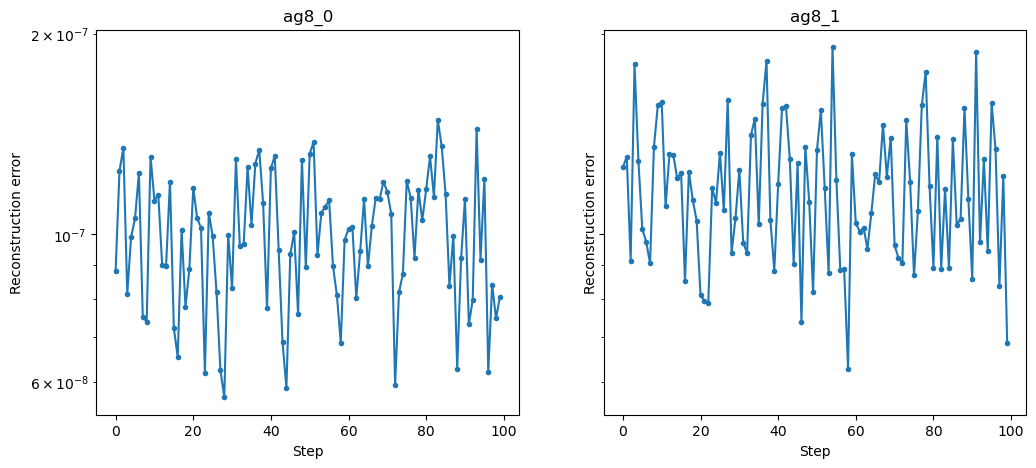

In [32]:
reconstruction_error = {key: [ (
    trajs_ag8[key][i].get_all_distances() - traj_rc_reconstructed[key][i].get_all_distances()
    ).std() for i in range(100)] for key in trajs_ag8.keys()}
                        

#plot the reconstruction error use log scale
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, ag8 in trajs_ag8.items():
    axs[int(i)].plot(reconstruction_error[i], '.-')
    axs[int(i)].set_xlabel('Step')
    axs[int(i)].set_ylabel('Reconstruction error')
    axs[int(i)].set_title(f'ag8_{i}')
    axs[int(i)].set_yscale('log')


## 2.b RC coordinates analysis

In [33]:
x_intern_1 = x_rcs['0'].to_numpy()
x_rcs['0'].agg(['min', 'max', 'mean', 'std'], axis=0)

,b-0-6,b-1-0,b-2-0,b-4-2,b-5-4,b-7-5,b-3-7,a-1-0-6,a-2-0-1,a-4-2-0,...,d-2-0-1-6,d-4-2-0-1,d-5-4-2-0,d-7-5-4-2,d-3-7-5-4,potential_energy,isomer,logdetjac,C,R
min,-0.175629,-0.141225,-0.144875,-0.215051,-0.150881,-0.130354,-0.165789,-0.094564,-0.110459,-0.082397,...,-0.183520,-0.030637,-0.079282,-0.255784,-0.100616,-65.587582,0.0,13.398451,17.558736,2.296986
max,0.365447,0.268336,0.192008,0.219586,0.249203,0.279822,0.269063,0.055070,0.065201,0.073778,...,0.016693,0.137724,0.138826,0.035050,0.190935,-65.248985,0.0,14.068585,19.811362,2.367707
mean,0.054517,0.082474,0.069437,0.033781,0.044860,0.037073,-0.010258,-0.032006,-0.031126,-0.018768,...,-0.062334,0.072582,0.038652,-0.082308,0.034533,-65.417362,0.0,13.764920,18.816644,2.330544
std,0.119497,0.116879,0.080098,0.096525,0.091140,0.104938,0.085671,0.038325,0.052184,0.035766,...,0.050913,0.038249,0.055987,0.081819,0.085261,0.072311,0.0,0.151530,0.521583,0.016787


In [34]:
x_intern_2 = x_rcs['1'].to_numpy()
x_rcs['1'].agg(['min', 'max', 'mean', 'std'], axis=0)

,b-0-6,b-1-0,b-2-0,b-4-2,b-5-4,b-7-5,b-3-7,a-1-0-6,a-2-0-1,a-4-2-0,...,d-2-0-1-6,d-4-2-0-1,d-5-4-2-0,d-7-5-4-2,d-3-7-5-4,potential_energy,isomer,logdetjac,C,R
min,-0.159253,-0.224499,-0.133893,-0.391396,-0.223869,-0.181996,0.006889,-0.070149,-0.109555,-0.097333,...,-0.120016,-0.084555,-0.101719,-0.083296,-0.095371,-65.543409,1.0,14.546134,17.760535,2.222258
max,0.178118,0.189941,0.351825,0.068289,0.140742,0.370509,0.460684,0.072911,0.025780,0.148110,...,0.192826,0.142860,0.399568,0.311437,0.212399,-65.152281,1.0,15.201682,20.333053,2.299741
mean,0.027732,0.000449,0.115746,-0.079413,-0.052344,0.138460,0.183360,0.003768,-0.027453,0.020021,...,0.059185,0.029078,0.121962,0.094835,0.060877,-65.332699,1.0,14.839015,19.253840,2.257266
std,0.095315,0.101344,0.126529,0.121063,0.087524,0.149090,0.118460,0.036255,0.030799,0.063588,...,0.090195,0.062418,0.141364,0.122819,0.084873,0.087503,0.0,0.183803,0.620131,0.018328


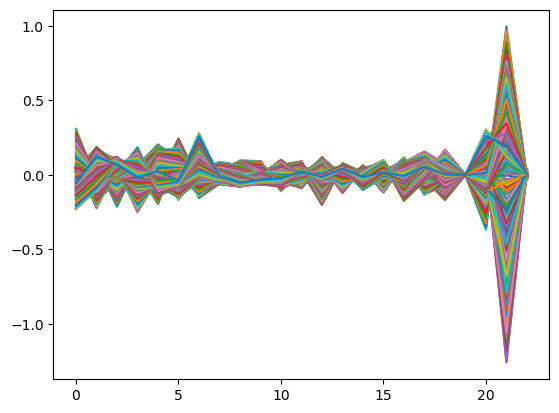

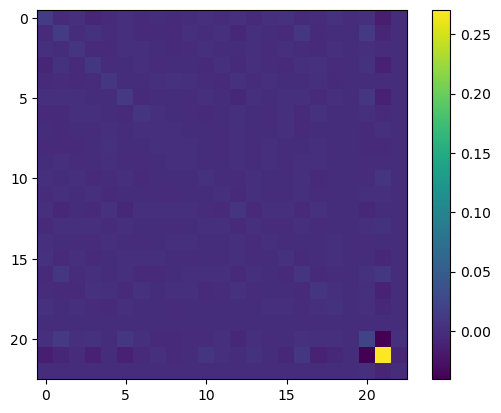

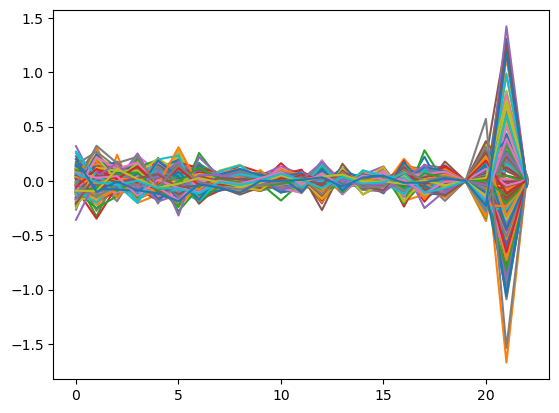

In [35]:
# Whitening
n_samples, dim = x_intern_1.shape

x_center = (x_intern_1 - x_intern_1.mean(0))
plt.plot(x_center.T)

plt.figure()
cov = x_center.T @ x_center / n_samples
plt.imshow(cov)
plt.colorbar()

eval, evec = np.linalg.eigh(cov)
x_center_gauss = np.random.multivariate_normal(np.zeros(dim), cov, size=n_samples)

plt.figure()
_ = plt.plot(x_center_gauss.T)

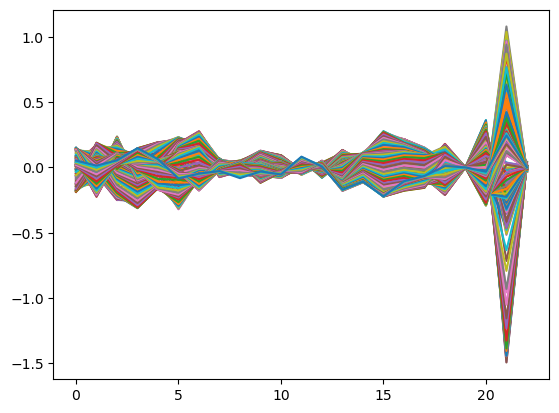

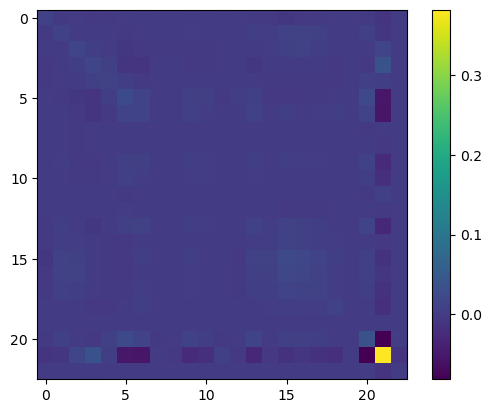

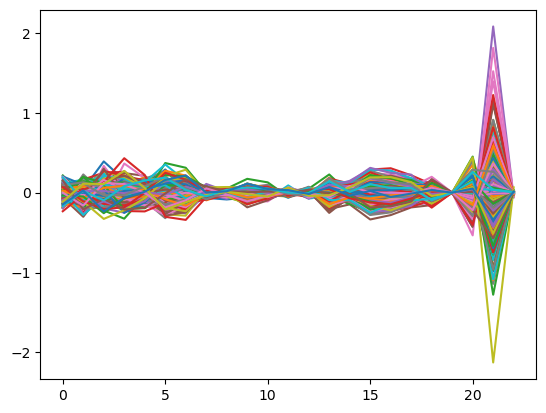

In [36]:
n_samples = x_intern_2.shape[0]
x_center = (x_intern_2 - x_intern_2.mean(0))
plt.plot(x_center.T)

plt.figure()
cov = x_center.T @ x_center / n_samples
plt.imshow(cov)
plt.colorbar()

eval, evec = np.linalg.eigh(cov)
x_center_gauss = np.random.multivariate_normal(np.zeros(dim), cov, size=n_samples)

plt.figure()
_ = plt.plot(x_center_gauss.T)